In [1]:
import os

import torch
from sclsd.train import LSD
from sclsd.core import LSDConfig
from sclsd.plotting import plot_random_walks
from sclsd.utils import set_all_seeds
from sclsd.utils.seed import clear_pyro_state
import scanpy as sc

/scratch/apour/conda/envs/sclsd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configure computational device
# Using GPU for faster training (change to 'cpu' if no GPU available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed for reproducibility
SEED = 42
set_all_seeds(SEED)


Using device: cuda


In [3]:
# Load preprocessed single-cell data
# This dataset has already been normalized and includes:
# - Log-normalized gene expression in .X
# - Raw counts in .layers['raw']
# - Library sizes in .obs['librarysize']
# - Prior pseudotime in .obs['prior_pseudotime']
# - Cell type annotations in .obs['clusters']

adata = sc.read("../../Zenodo/Erythroid/preprocessed_adata.h5ad")

# Define the differentiation phylogeny
# This represents the known biological progression of erythroid differentiation
# Each key maps to its allowed successor cell types

phylogeny = {
    'Blood progenitors 1': ['Blood progenitors 2'], 
    'Blood progenitors 2': ['Erythroid1'],           
    'Erythroid1': ['Erythroid2'],                    
    'Erythroid2': ['Erythroid3'],                    
    'Erythroid3': []                                 
}

print("Differentiation phylogeny defined:")
for parent, children in phylogeny.items():
    if children:
        print(f"  {parent} → {', '.join(children)}")
    else:
        print(f"  {parent} (terminal state)")

Differentiation phylogeny defined:
  Blood progenitors 1 → Blood progenitors 2
  Blood progenitors 2 → Erythroid1
  Erythroid1 → Erythroid2
  Erythroid2 → Erythroid3
  Erythroid3 (terminal state)


In [4]:
# Initialize the LSD model
print("Initializing LSD model...")
cfg = LSDConfig()

cfg.model.V_coeff = 5e-3
cfg.optimizer.kl_schedule.af = 3
cfg.walks.path_len = 16
cfg.walks.random_state = SEED


lsd = LSD(
    adata,                           # Single-cell data
    cfg,
    device=device,                   # Computation device (GPU/CPU)
    lib_size_key="librarysize",      # Column name for library sizes
    raw_count_key="raw",             # Layer name for raw counts
)

print("Model initialized successfully!")
print(f"  Cell state dimension: {lsd.z_dim}")
print(f"  Differentiation state dimension: {lsd.B_dim}")

Initializing LSD model...


Model initialized successfully!
  Cell state dimension: 10
  Differentiation state dimension: 2


In [5]:
# Set phylogeny constraints and prior transitions
# This incorporates biological knowledge into the model

print("Setting phylogeny constraints...")
lsd.set_phylogeny(phylogeny, cluster_key="clusters")

print("\nSetting prior transition matrix from pseudotime...")
lsd.set_prior_transition(prior_time_key="prior_pseudotime")

print("\nBiological constraints successfully incorporated into model")

Setting phylogeny constraints...

Setting prior transition matrix from pseudotime...
[LSD] Removing 2 cells with no transitions:
[LSD] Prior transition matrix set from phylogeny and pseudotime.

Biological constraints successfully incorporated into model


Generating random walk trajectories...


Random walks generated successfully!
  Shape of walks: torch.Size([4096, 16])

Visualizing random walks on UMAP embedding...


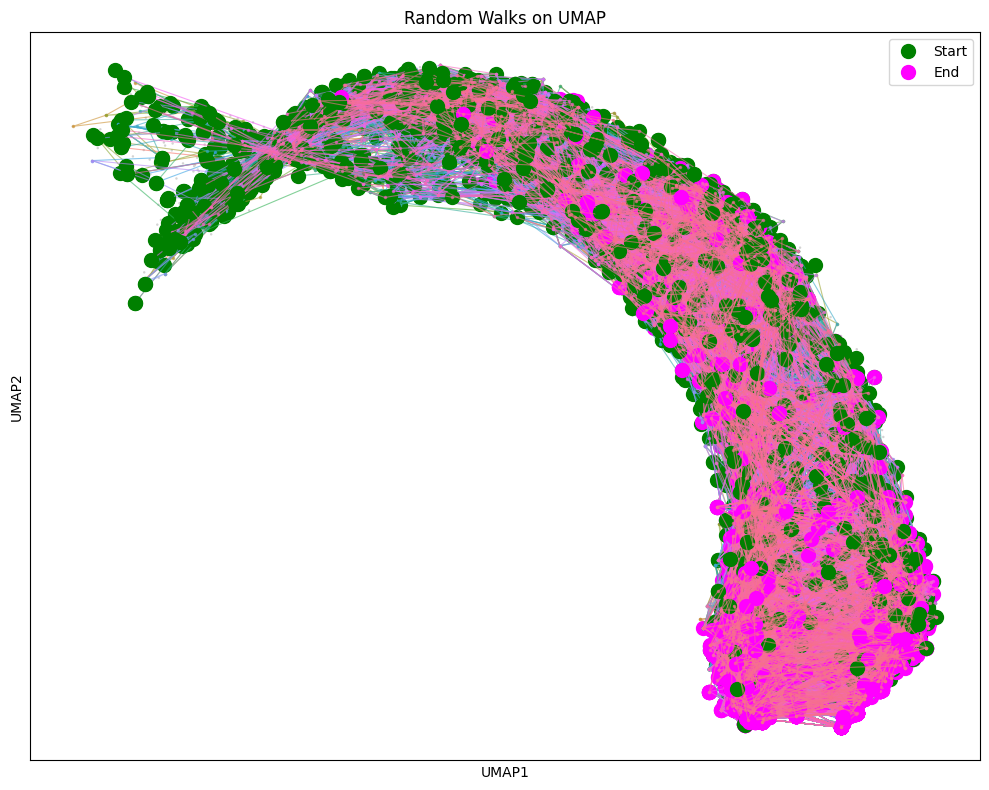

In [6]:
# Generate random walks on the cell connectivity graph
# These trajectories are used to train smooth dynamics

print(f"Generating random walk trajectories...")
lsd.prepare_walks()

print("Random walks generated successfully!")
print(f"  Shape of walks: {lsd.walks.shape}")

# Visualize a sample of random walks on UMAP
print("\nVisualizing random walks on UMAP embedding...")
plot_random_walks(lsd.adata, lsd.walks, "X_umap")


Pyro parameter store cleared
Model checkpoints will be saved to: ./model

Starting model training...
This may take 20-30 minutes depending on GPU



Training Epochs: 100%|██████████| 150/150 [20:49<00:00,  8.33s/it, -ELBO=2.2511, Potential Metric=0.5058, Entropy Metric=0.0545]


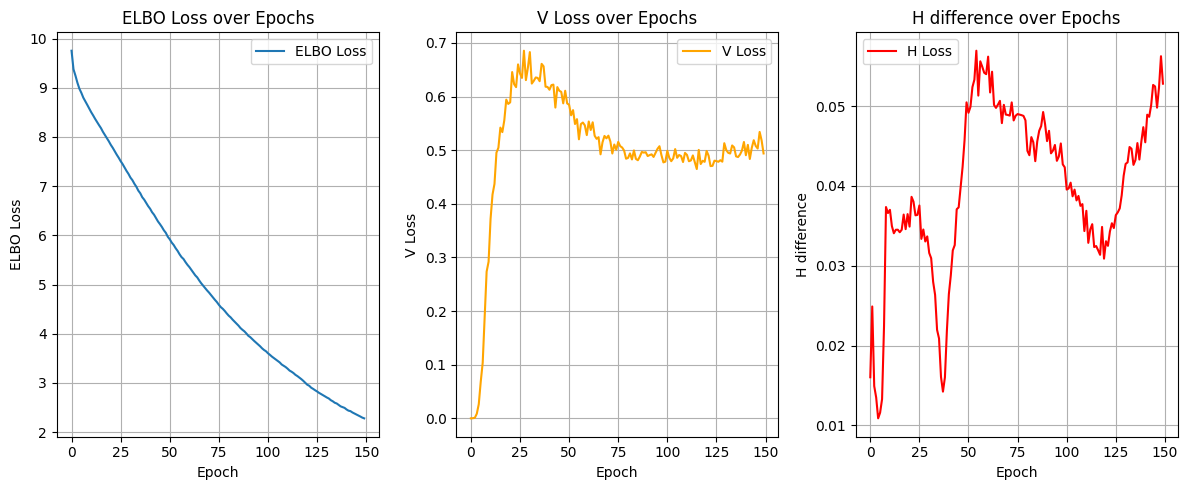


Training completed successfully!


In [7]:
# Clear any existing parameters from previous runs
clear_pyro_state()
print("Pyro parameter store cleared")

# Create save directory for model checkpoints
save_dir = "./model"
os.makedirs(save_dir, exist_ok=True)
print(f"Model checkpoints will be saved to: {save_dir}")

num_epochs = 150

print("\n" + "="*50)
print("Starting model training...")
print("="*50)
print("This may take 20-30 minutes depending on GPU")
print("")

# Train the model
lsd.train(
    num_epochs=num_epochs,      # Total training epochs
    save_dir=save_dir,          # Directory for checkpoints
    save_interval=50,           # Save model every 50 epochs
    random_state=SEED             # Random seed for reproducibility
)

print("\n" + "="*50)
print("Training completed successfully!")
print("="*50)